In [6]:
%load_ext autoreload
%autoreload 2

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import wandb
import torchvision
from tqdm import tqdm
import torch.nn.functional as F
from tqdm import tqdm

from softadapt import SoftAdapt, NormalizedSoftAdapt, LossWeightedSoftAdapt

sys.path.append(os.path.join(os.getcwd(), '../symlie'))
sys.path.append(os.path.join(os.getcwd(), '../'))

from symlie.model.networks.mlp import CombiMLP
from symlie.model.learner import CombiLearner
from symlie.run import parse_options, main, process_args

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from emlp.reps import V
from emlp.groups import Z, O
from emlp.datasets import O5Synthetic
from emlp.nn import uniform_rep

In [3]:
set = O5Synthetic(N = 1)
group, repin, repout = O(5), set.rep_in, set.rep_out
repin, repout = repin(group), repout(group)
repin, repout

(2V, V⁰)

In [16]:
ch = [10]
for c in ch:
    u = uniform_rep(c, group) 
    print(u)

5V⁰+V


In [11]:
args = parse_options(notebook=True)
args.config = 'emlp'
args.do_return = False
args.logger = None

args.bias = True
args.lossweight_y = 1.
args.lossweight_o = 0.

process_args(args)

# Training
model_emlp, trainer_emlp, datamodule_emlp = main(args)

Seed set to 1


(V+V) V⁰ O(5) [10]
Initing EMLP (PyTorch)
ch [10] False False
middle layers!
[2V, 5V⁰+V]
V⁰
for loop
2V 5V⁰+V
10 10
Exiting!


SystemExit: 

In [4]:
args = parse_options(notebook=True)
args.config = 'o5synth'
# args.do_return = True
# args.logger = None

# args.implicit_layer_dims = [[100, 100, 100], [10, 10, 10]]
args.implicit_layer_dims = [[110, 110, 110, 110], [11, 11, 11, 11]]
args.implicit_layer_dims = [[0], [0]]
# args.implicit_layer_dims = [[110, 110], [11, 11]]
# args.grid_sizes = [[[1,2,5], [1,2,5]], [[1,1,1], [1,2,5]]]
args.bias = True
# args.lossweight_y = 0.
# args.lossweight_o = 1.
args.lossweight_y = 1.
args.lossweight_o = 0.

process_args(args)

# Training
model, trainer, datamodule = main(args)

Seed set to 1


Init rng


/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:389: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Running chocolate-oath-3079 with id 6xudkg2n
Print parameters in configure_optimizers
net.vanilla_layers.0.weight True
net.vanilla_layers.0.bias True
net.vanilla_layers.1.weight True
net.vanilla_layers.1.bias True

Epoch 477:  73%|███████▎  | 46/63 [00:00<00:00, 477.54it/s, v_num=kg2n, val_loss_y=11.80, val_loss=11.80, train_loss_y=14.60, train_loss=14.60]

/Users/elias/anaconda3/envs/sympde/lib/python3.10/site-packages/pytorch_lightning/trainer/call.py:54: Detected KeyboardInterrupt, attempting graceful shutdown...


Testing DataLoader 0: 100%|██████████| 63/63 [00:00<00:00, 690.58it/s]
Logged regression results


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    16.090375900268555     │
│        test_loss_y        │    16.090375900268555     │
└───────────────────────────┴───────────────────────────┘

wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
test_loss,▁
test_loss_y,▁
train_loss,█▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_y,█▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
val_loss,█▄▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss_y,█▄▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,477
test_loss,16.09038
test_loss_y,16.09038


In [66]:
train_data_loader = datamodule.train_dataloader()
it = iter(train_data_loader)
x, y, centers_ = batch = next(it)
rng = torch.Generator()

In [62]:
x_prime = model.transform(
    x,
    rng = rng,
    shape = (1, 2, 5)
)

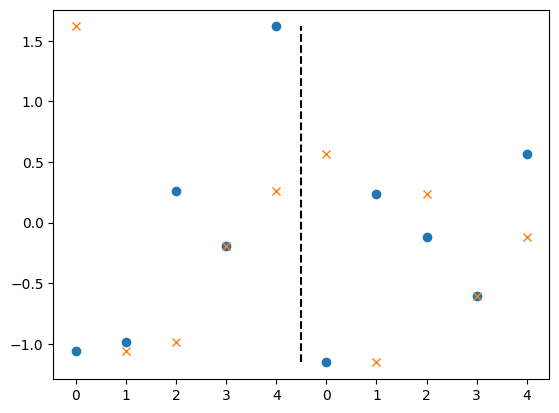

In [63]:
def plot_equiv(a, b, i = 0):
    a_i, b_i = a[i], b[i]
    plt.plot(a_i, 'o')
    plt.plot(b_i, 'x')
    minn, maxx = min(a_i.min(), b_i.min()), max(a_i.max(), b_i.max())
    plt.vlines(4.5, minn, maxx, color='black', linestyle='--')
    plt.xticks(range(10), np.tile(np.arange(5), 2))
    plt.show()

plot_equiv(x, x_prime)

In [127]:
outs = model(batch)

torch.Size([1, 10]) torch.Size([1, 1])


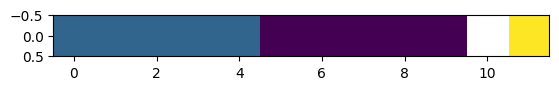

torch.Size([1, 10]) torch.Size([1, 1])


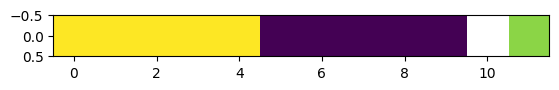

In [26]:
w, b = model.net.implicit_layers[1](
    model.net.vanilla_layers[1].weight.data.clone(),  model.net.vanilla_layers[1].bias.data.clone()
)

def wb_plot_pred(w, b):
    b = b.view(-1, 1)

    print(w.shape, b.shape)

    return torch.cat([
        w,
        torch.full_like(b, torch.nan),
        b,
    ], dim = 1).detach().numpy()

plt.imshow(wb_plot_pred(w, b))
plt.show() 

w = torch.rand_like(w)
b = torch.rand_like(b)

n = 10
assert w.shape == (1, n)
assert b.shape == (1,), b.shape

nn = n // 2
wp = torch.cat([torch.zeros(nn), torch.ones(nn)])

wb = torch.tensor([0])

w, b = (w.flatten()[wp.flatten().long()]).reshape(w.shape), b.flatten()[wb.long()]

plt.imshow(wb_plot_pred(w, b))
plt.show()

In [90]:
model.net(x)

tensor([[-0.0808],
        [-0.0947],
        [ 0.0065],
        [ 0.0467],
        [-0.1174],
        [ 0.1216],
        [ 0.0304],
        [-0.0384],
        [-0.0219],
        [ 0.0310],
        [-0.0906],
        [ 0.0490],
        [-0.0555],
        [-0.0039],
        [-0.0703],
        [ 0.0142]], grad_fn=<AddmmBackward0>)

In [89]:
x.shape

torch.Size([16, 10])

In [93]:
from symlie.data.transforms import Transform, TransformRefactored

class TransformationBlock(TransformRefactored):
    def __init__(self, transform_kwargs, **kwargs):
        TransformRefactored.__init__(self, eps_mult = transform_kwargs['eps_mult'])
        self.rng_a, self.rng_b = torch.Generator(), torch.Generator()

        # self.my_forward = nn.ReLU()
        self.my_forward = model.net


    def forward_transformation(self, x, shape):
        self.rng_b.set_state(self.rng_a.get_state())

        x_a, x_b = x, x
        shape = {'a':shape[0], 'b':shape[1]}


        # Route a: Forward pass, transformation
        out_a = self.my_forward(x_a)
        out_a_prime = self.transform(out_a, self.rng_a, shape=shape['a'])

        # Route b: Transformation, forward pass
        x_b_prime = self.transform(x_b, self.rng_b, shape=shape['b'])
        out_b_prime = self.my_forward(x_b_prime)

        assert out_a_prime.shape == out_b_prime.shape

        return (out_a_prime, out_b_prime)
    
transform = TransformationBlock(
    transform_kwargs = {
        'eps_mult': [0, 0, 0, 0],
    }
)

out = transform.forward_transformation(x, [(1,1,1),(1, 2, 5)])

torch.allclose(out[0], out[1])

True

In [9]:
x = torch.randn(10,)

def f(x):
    return -x

def g(x):
    return F.relu(x)

torch.allclose(f(g(x)), g(f(x)))

False

In [4]:
w, b = model.net.implicit_layers[0](
    model.net.vanilla_layers[0].weight.data.clone(),  model.net.vanilla_layers[0].bias.data.clone()
)

o = F.linear(x, w, b)

o2 = F.relu(o)

o2_prime = model.transform(
    o2,
    rng = rng,
    shape = (1, 2, 5)
)

plot_equiv(o2, o2_prime)

NameError: name 'model' is not defined

In [76]:
o2[0].reshape(2, 5), o2_prime[0].reshape(2, 5)

(tensor([[1.0127, 1.0210, 1.0056, 1.0280, 1.0400],
         [0.2369, 0.1153, 0.1167, 0.2920, 0.3535]]),
 tensor([[1.0280, 1.0400, 1.0210, 1.0127, 1.0056],
         [0.2920, 0.3535, 0.1153, 0.2369, 0.1167]]))

torch.Size([10, 10]) torch.Size([10])
torch.Size([10, 10]) torch.Size([10, 1])


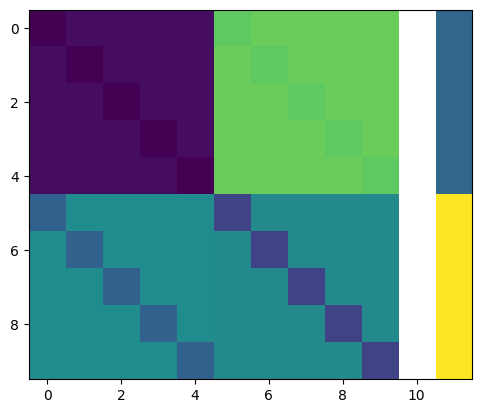

torch.Size([10, 10]) torch.Size([10, 1])


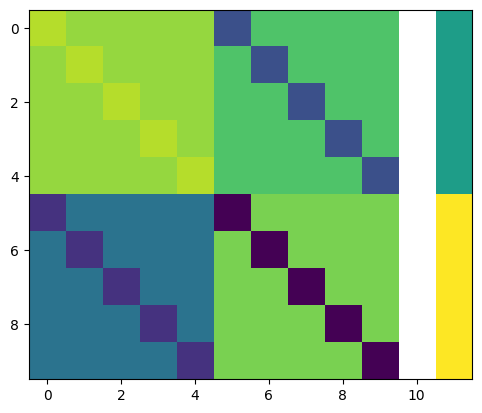

In [29]:
w, b = model.net.implicit_layers[0](
    model.net.vanilla_layers[0].weight.data.clone(),  model.net.vanilla_layers[0].bias.data.clone()
)
print(w.shape, b.shape)
plt.imshow(wb_plot_pred(w, b))
plt.show() 

w = torch.rand_like(w)
b = torch.rand_like(b)

n = 10
assert w.shape == (n, n)
assert b.shape == (n,), b.shape

nn = n // 2
i1 = torch.zeros(nn)
i1[0] = 1
i2 = torch.cat([i1])
i3 = torch.stack([torch.roll(i2, j, 0) for j in range(nn)])
i4 = i3 + 2
i5 = torch.cat([i3, i4], dim=1)
i6 = i5 + 4
wp = torch.cat([i5, i6], dim=0)

wb = torch.cat([torch.zeros(nn), torch.ones(nn)])


w, b = (w.flatten()[wp.flatten().long()]).reshape(w.shape), b.flatten()[wb.long()]

plt.imshow(wb_plot_pred(w, b))
plt.show()

In [14]:
b

tensor([-0.0047, -0.0047, -0.0047, -0.0047, -0.0047,  0.0378,  0.0378,  0.0378,
         0.0378,  0.0378], grad_fn=<SelectBackward0>)

In [ ]:
train_data_loader = datamodule.train_dataloader()
# x, y, _ = batch = next(iter(train_data_loader))

In [ ]:
outs = model(batch)
print(len(outs))

In [ ]:
F.mse_loss(*outs[0]), F.mse_loss(*outs[1]), F.mse_loss(*outs[2])

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)

In [ ]:
# Assume `model`, `optimizer` and the dataloader are defined
# We assume optimization is being done with 3 loss function
loss_component_1 = nn.MSELoss()
loss_component_2 = nn.MSELoss()
loss_component_3 = nn.MSELoss()

# Main training loop:
for current_epoch in tqdm(range(args.max_epochs)):
  for batch_idx, batch in enumerate(train_data_loader):
      x, y, centers = batch
      optimizer.zero_grad()
      outs = model(batch)
      loss = loss_component_1(*outs[0]) + loss_component_2(*outs[1]) + loss_component_3(*outs[2])

      loss.backward()
      optimizer.step()


In [ ]:
batch_idx

In [ ]:
# Assume `model`, `optimizer` and the dataloader are defined
# We assume optimization is being done with 3 loss function
loss_component_1 = nn.MSELoss()
loss_component_2 = nn.MSELoss()
loss_component_3 = nn.MSELoss()

# Change 1: Create a SoftAdapt object (with your desired variant)
softadapt_object = LossWeightedSoftAdapt(beta=0.1)

# Change 2: Define how often SoftAdapt calculate weights for the loss components
epochs_to_make_updates = 5

# Change 3: Initialize lists to keep track of loss values over the epochs we defined above
values_of_component_1 = []
values_of_component_2 = []
values_of_component_3 = []
# Initializing adaptive weights to all ones.
adapt_weights = torch.tensor([1,1,1])


# Main training loop:
for current_epoch in tqdm(range(args.max_epochs)):
  for batch_idx, batch in enumerate(train_data_loader):
      x, y, centers = batch
      optimizer.zero_grad()
      outs = model(batch)

      # Keeping track of each loss component
      values_of_component_1.append(loss_component_1(*outs[0]))
      values_of_component_2.append(loss_component_2(*outs[1]))
      values_of_component_3.append(loss_component_3(*outs[2]))

      # Change 4: Make sure `epochs_to_make_change` have passed before calling SoftAdapt.
      if current_epoch % epochs_to_make_updates == 0 and current_epoch != 0:
          adapt_weights = softadapt_object.get_component_weights(torch.tensor(values_of_component_1), 
                                                                 torch.tensor(values_of_component_2), 
                                                                 torch.tensor(values_of_component_3),
                                                                 verbose=False,
                                                                 )
                                                            
      
          # Resetting the lists to start fresh (this part is optional)
          values_of_component_1 = []
          values_of_component_2 = []
          values_of_component_3 = []
      
      # Change 5: Update the loss function with the linear combination of all components.
      loss = adapt_weights[0]*loss_component_1(*outs[0]) + adapt_weights[1]*loss_component_2(*outs[1]) + adapt_weights[2]*loss_component_3(*outs[2])

      loss.backward()
      optimizer.step()


In [ ]:
# Assume `model`, `optimizer` and the dataloader are defined
# We assume optimization is being done with 3 loss function
loss_component_1 = nn.MSELoss()
loss_component_2 = nn.MSELoss()
loss_component_3 = nn.MSELoss()

# Change 1: Create a SoftAdapt object (with your desired variant)
softadapt_object = LossWeightedSoftAdapt(beta=0.1)

# Change 2: Define how often SoftAdapt calculate weights for the loss components
epochs_to_make_updates = 5

# Change 3: Initialize lists to keep track of loss values over the epochs we defined above
values_of_component_1 = []
values_of_component_2 = []
values_of_component_3 = []
# Initializing adaptive weights to all ones.
adapt_weights = torch.tensor([1,1,1])


# Main training loop:
for current_epoch in tqdm(range(args.max_epochs)):
    # Change 4: Make sure `epochs_to_make_change` have passed before calling SoftAdapt.
    if current_epoch % epochs_to_make_updates == 0 and current_epoch != 0:
        print(torch.tensor(values_of_component_1))
        adapt_weights = softadapt_object.get_component_weights(torch.tensor(values_of_component_1), 
                                                                torch.tensor(values_of_component_2), 
                                                                torch.tensor(values_of_component_3),
                                                                verbose=True,
                                                                )
                                                        

        # Resetting the lists to start fresh (this part is optional)
        values_of_component_1 = []
        values_of_component_2 = []
        values_of_component_3 = []
    for batch_idx, batch in enumerate(train_data_loader):
        x, y, centers = batch
        optimizer.zero_grad()
        outs = model(batch)

        # Keeping track of each loss component
        values_of_component_1.append(loss_component_1(*outs[0]))
        values_of_component_2.append(loss_component_2(*outs[1]))
        values_of_component_3.append(loss_component_3(*outs[2]))

        
        # Change 5: Update the loss function with the linear combination of all components.
        loss = adapt_weights[0]*loss_component_1(*outs[0]) + adapt_weights[1]*loss_component_2(*outs[1]) + adapt_weights[2]*loss_component_3(*outs[2])

        loss.backward()
        optimizer.step()


In [ ]:
torch.tensor(values_of_component_1).shape

In [ ]:
loss_component_1 = MyCriterion1()
loss_component_2 = MyCriterion2()
loss_component_3 = MyCriterion3()

# Change 1: Create a SoftAdapt object (with your desired variant)
softadapt_object = LossWeightedSoftAdapt(beta=0.1)

# Change 2: Define how often SoftAdapt calculate weights for the loss components
epochs_to_make_updates = 5

# Change 3: Initialize lists to keep track of loss values over the epochs we defined above
values_of_component_1 = []
values_of_component_2 = []
values_of_component_3 = []
# Initializing adaptive weights to all ones.
adapt_weights = torch.tensor([1,1,1])

# Main training loop:
for current_epoch in range(training_epochs):
    # Change 4: Make sure `epochs_to_make_change` have passed before calling SoftAdapt.
    if current_epoch % epochs_to_make_updates == 0 and current_epoch != 0:
        adapt_weights = softadapt_object.get_component_weights(torch.tensor(values_of_component_1), 
                                                               torch.tensor(values_of_component_2), 
                                                               torch.tensor(values_of_component_3),
                                                               verbose=False,
                                                               )  

        # Resetting the lists to start fresh (this part is optional)
        values_of_component_1 = []
        values_of_component_2 = []
        values_of_component_3 = []

    for batch_idx, data in enumerate(train_data_loader):
        features, labels = data
        optimizer.zero_grad()
        outputs, _, _ = model(features.float())
        # Keeping track of each loss component
        values_of_component_1.append(loss_component_1(outputs))
        values_of_component_2.append(loss_component_2(outputs))
        values_of_component_3.append(loss_component_3(outputs))

        # Change 5: Update the loss function with the linear combination of all components.
        loss = adapt_weights[0] * loss_component_1(outputs) + adapt_weights[1]*loss_component_2(outputs) + adapt_weights[2]*loss_component_3(outputs)

        loss.backward()
        optimizer.step()


In [ ]:
from softadapt import SoftAdapt, NormalizedSoftAdapt, LossWeightedSoftAdapt
import torch
# We redefine the loss components above for the sake of completeness.
loss_component_1 = torch.tensor([1, 2, 3, 4, 500.1])
loss_component_2 = torch.tensor([150, 100, 50, 10, 0.1])
loss_component_3 = torch.tensor([1500, 1000, 500, 100, 1])

# Here we define the different SoftAdapt objects
loss_weighted_softadapt_object  = LossWeightedSoftAdapt(beta=0.1)

In [ ]:
loss_weighted_softadapt_object.get_component_weights(loss_component_1, loss_component_2, loss_component_3)
#>>> tensor([8.7978e-01, 1.2022e-01, 7.1234e-20]